In [1]:
'''Imports'''
import os
import numpy as np
from pathlib import Path
import pandas as pd 
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from PIL import Image
import io
from matplotlib import cm, ticker

In [2]:
'''Set filenames'''
dataDirName = "biggerDomainData/"
dataNames = "df."
dataExt = ".csv"

In [3]:
'''Count number of rows in each file'''
# for i in range(10):
#     df = dataNames + str(i) + dataExt
#     print(df)

# Sort key 
# - https://stackoverflow.com/questions/7304117/split-filenames-with-python
# - https://stackoverflow.com/questions/33159106/sort-filenames-in-directory-in-ascending-order
def extract_number(file_path):
    # For an example input of "df.10.csv" ...
    # .stem - takes off extension "df.10"
    # .split('.')[1] - splits into two elements "df" and "10" surrounding the ".", then selects the second element "10"
    return int(file_path.stem.split('.')[1])
dfNames = sorted(Path(dataDirName).glob('*.csv'), key=extract_number)
# test = dfNames[1]
# test3 = test.name

# Get number of data files
N = len(dfNames)

# Get data file names in a separate list
dfNamesList = [file.name for file in dfNames]
# print(dataDirName + dfNamesList[1])

# Get number of rows for each file - https://stackoverflow.com/questions/16108526/how-to-obtain-the-total-numbers-of-rows-from-a-csv-file-in-python
#   to make sure they're all the same length
rows = []
cols = []
for i in range(N):
    rows.append(pd.read_csv(dataDirName + dfNamesList[i]).shape[0])
    cols.append(pd.read_csv(dataDirName + dfNamesList[i]).shape[1])
# cols.append(5)

# Check that all of them are the same number of rows
avgRows = np.mean(rows)
avgCols = np.mean(cols)
if avgRows != rows[0] or avgCols != cols[0]:
    print("          Some files have inconsistent dimensions.  \n\
          The average numer of rows is %d, and the first file has %d rows. \n\
          The average numer of columns is %d, and the first file has %d columns." % (avgRows, rows[0], avgCols, cols[0]))
    raise
else:
    M = rows[0]

In [4]:
'''Gather all csv data into a variable for easy plotting'''
# Set times
dt = 0.001
times = dt + np.arange(0,N) * dt

# Set desired column names
desData = ["overpressure", "U:0", "U:1", "U:2", "Points:0", "Points:1", "timeOfArrival"]

# Initialize arrays
overpressure = np.zeros((M,N))
u0 = np.zeros((M,N))
u1 = np.zeros((M,N))
u2 = np.zeros((M,N))
x = np.zeros((M,N))
y = np.zeros((M,N))
timeOfArrival = np.zeros((M,N))

# Get data
for i in range(N):
    data = pd.read_csv(dataDirName + dfNamesList[i], usecols = desData)
    # test = data[desData]
    overpressure[:, i], u0[:, i], u1[:, i], u2[:, i], x[:, i], y[:, i], timeOfArrival[:, i] = data[desData].values.T

r = np.hypot(x[:, 0], y[:, 0])
U = np.stack((u0,u1,u2),axis=2)
V = np.linalg.norm(U,axis=2)


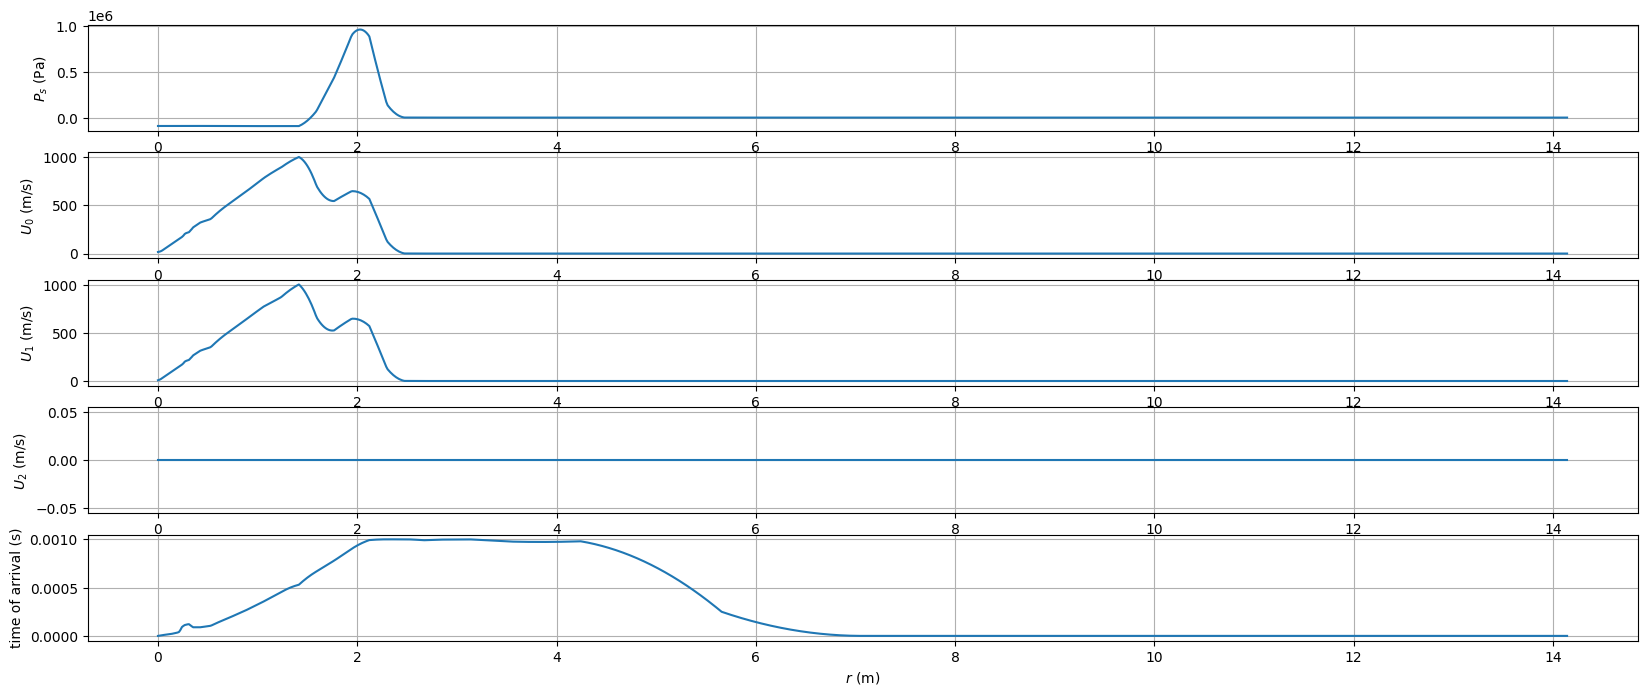

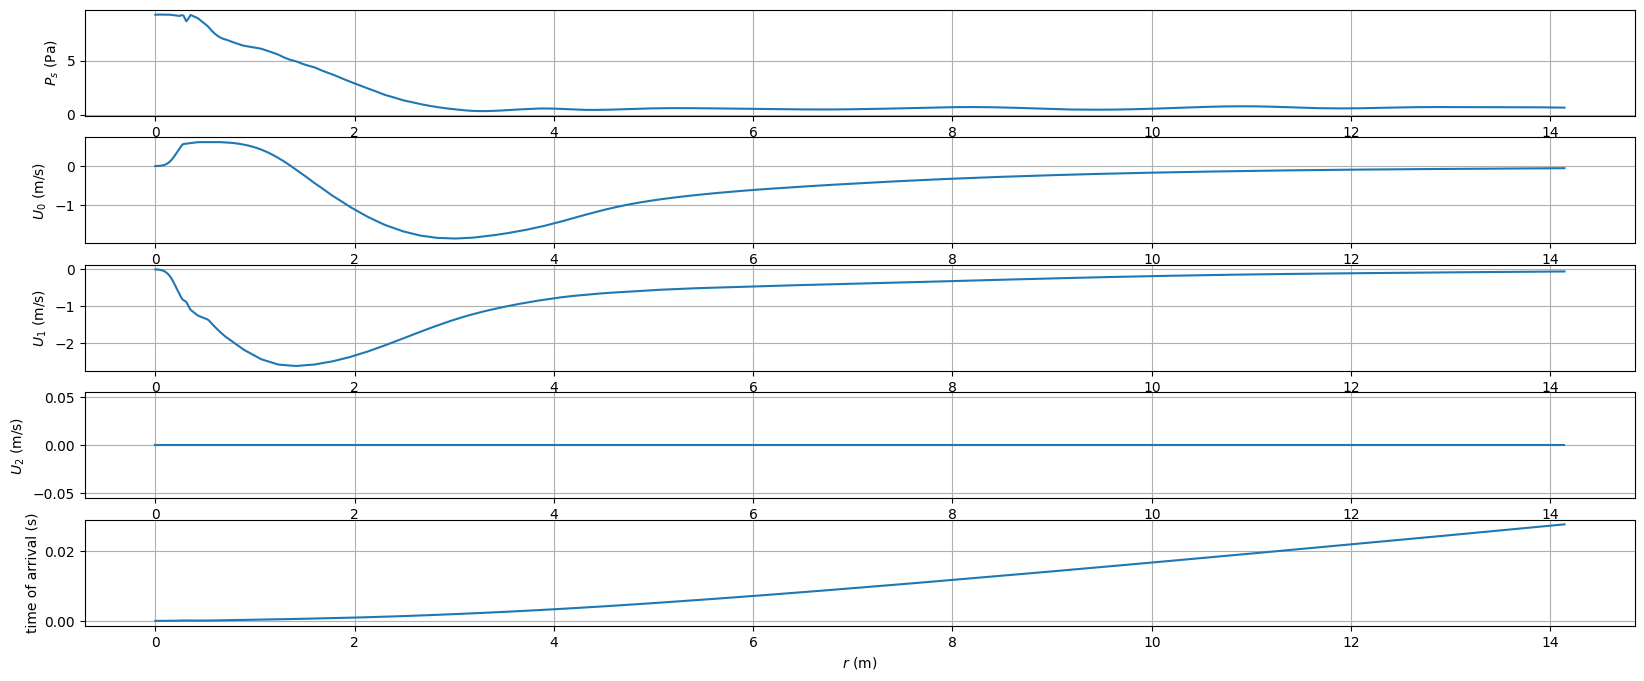

In [5]:
'''Plot first and last timesteps'''
# Make a plot
idx = 0
fig, ax = plt.subplots(nrows=5,ncols=1,figsize=(20,8))

# Overpressure
ax[0].plot(r,overpressure[:,idx])
ax[0].set_ylabel(r'$P_{s}$ (Pa)')
ax[0].grid(True)

# U0 - xdot?
ax[1].plot(r,u0[:,idx])
ax[1].set_ylabel(r'$U_{0}$ (m/s)')
ax[1].grid(True)

# U1 - ydot?
ax[2].plot(r,u1[:,idx])
ax[2].set_ylabel(r'$U_{1}$ (m/s)')
ax[2].grid(True)

# U2 - zdot?
ax[3].plot(r,u2[:,idx])
ax[3].set_ylabel(r'$U_{2}$ (m/s)')
ax[3].grid(True)

# time of arrival
ax[4].plot(r,timeOfArrival[:,idx])
ax[4].set_ylabel(r'time of arrival (s)')
ax[4].set_xlabel(r'$r$ (m)')
ax[4].grid(True)

# Make a plot
idx = N-1
fig, ax = plt.subplots(nrows=5,ncols=1,figsize=(20,8))

# Overpressure
ax[0].plot(r,overpressure[:,idx])
ax[0].set_ylabel(r'$P_{s}$ (Pa)')
ax[0].grid(True)

# U0 - xdot?
ax[1].plot(r,u0[:,idx])
ax[1].set_ylabel(r'$U_{0}$ (m/s)')
ax[1].grid(True)

# U1 - ydot?
ax[2].plot(r,u1[:,idx])
ax[2].set_ylabel(r'$U_{1}$ (m/s)')
ax[2].grid(True)

# U2 - zdot?
ax[3].plot(r,u2[:,idx])
ax[3].set_ylabel(r'$U_{2}$ (m/s)')
ax[3].grid(True)

# time of arrival
ax[4].plot(r,timeOfArrival[:,idx])
ax[4].set_ylabel(r'time of arrival (s)')
ax[4].set_xlabel(r'$r$ (m)')
ax[4].grid(True)

In [6]:
'''Plot things'''
# Set latex options for plots
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath,bm}'  # https://stackoverflow.com/questions/23824687/text-does-not-work-in-a-matplotlib-label
plt.rcParams['text.usetex'] = True

# Set temp plot directory name
tmpPltName = "frame"
tmpPltDir = "animationPlts/"
os.makedirs(tmpPltDir, exist_ok=True)

# Make all of the plots, save them as pngs
pltOnOff = 0
if pltOnOff == 1:
    for idx in range(N):
        # Make the figure
        fig, ax = plt.subplots(nrows=5,ncols=1,figsize=(20,8))

        # Overpressure
        ax[0].plot(r,overpressure[:,idx])
        ax[0].set_ylabel(r'$P_{s}$ (Pa)')
        ax[0].grid(True)

        # U0 - xdot?
        ax[1].plot(r,u0[:,idx])
        ax[1].set_ylabel(r'$U_{0}$ (m/s)')
        ax[1].grid(True)

        # U1 - ydot?
        ax[2].plot(r,u1[:,idx])
        ax[2].set_ylabel(r'$U_{1}$ (m/s)')
        ax[2].grid(True)

        # U2 - zdot?
        ax[3].plot(r,u2[:,idx])
        ax[3].set_ylabel(r'$U_{2}$ (m/s)')
        ax[3].grid(True)

        # Time of arrival
        ax[4].plot(r,timeOfArrival[:,idx])
        ax[4].set_ylabel(r'time of arrival (s)')
        ax[4].set_xlabel(r'$r$ (m)')
        ax[4].grid(True)

        # Save the plot as a png
        fig.savefig(tmpPltDir + tmpPltName + str(idx),format='png')

In [7]:
'''Colormap plotting function'''
def paramColormap(x,y,Z,label,yscale,fn):
    # Make the meshgrid
    X, Y = np.meshgrid(x,y)

    # Calculate levels
    N = 100
    lvls = np.linspace(np.min(Z), np.max(Z), N)
    
    # Make the figure
    fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(8,8))

    # Make the contourf plot - https://matplotlib.org/stable/gallery/images_contours_and_fields/contourf_log.html#sphx-glr-gallery-images-contours-and-fields-contourf-log-py
    # cs = ax.contourf(X, Y, Z, levels=lvls, locator=ticker.LogLocator(), cmap=cm.bone)
    # cs = ax.contourf(X, Y, Z, levels=lvls, cmap=cm.bone)
    cs = ax.contourf(X, Y, Z, cmap=cm.Spectral)
    cbar = fig.colorbar(cs)
    cbar.ax.set_ylabel(label)
    
    # Set titles
    # ax.set_title(label)
    ax.set_xlabel('Radius (m)')
    ax.set_ylabel('Time (sec)')
    ax.set_ylim((y[0],np.max(y)*yscale))
    # ax.set_aspect('equal', 'box')

    # Set scales
    # ax.set_xscale('log')
    # ax.set_yscale('log')

    # Save the plot
    fig.tight_layout()
    fig.savefig(fn + '.pdf')

# Fig directory
figDirName = 'contourfParamPlots/'
os.makedirs(figDirName, exist_ok=True)

In [8]:
# '''Overpressure plots'''
# paramColormap(r,times,overpressure.T,r'$P_{s}$ (Pa)',1/10,figDirName + 'Ps_smallR')
# paramColormap(r,times,overpressure.T,r'$P_{s}$ (Pa)',1,figDirName + 'Ps_fullR')

In [9]:
# '''Velocity magnitude plots'''
# paramColormap(r,times,V.T,r'$\left\| U \right\|$ (m/s)',1/20,figDirName + 'Vmag_smallR')
# paramColormap(r,times,V.T,r'$\left\| U \right\|$ (m/s)',1,figDirName + 'Vmag_fullR')

In [10]:
# '''Time of arrival plots'''
# paramColormap(r,times,timeOfArrival.T,'Time of arrival (sec)',1/10,figDirName + 'timeOfArrival_smallR')
# paramColormap(r,times,timeOfArrival.T,'Time of arrival (sec)',1,figDirName + 'timeOfArrival_fullR')

In [11]:
# '''Velocity component plots'''
# # u0
# paramColormap(r,times,u0.T,r'$U_{0}$ (m/s)',1/20,figDirName + 'u0_smallR')
# paramColormap(r,times,u0.T,r'$U_{0}$ (m/s)',1,figDirName + 'u0_fullR')

# # u1
# paramColormap(r,times,u1.T,r'$U_{1}$ (m/s)',1/20,figDirName + 'u1_smallR')
# paramColormap(r,times,u1.T,r'$U_{1}$ (m/s)',1,figDirName + 'u1_fullR')

# # u2
# paramColormap(r,times,u2.T,r'$U_{2}$ (m/s)',1/20,figDirName + 'u2_smallR')
# paramColormap(r,times,u2.T,r'$U_{2}$ (m/s)',1,figDirName + 'u2_fullR')

In [33]:
'''Function to plot param over time at a specific radius from the blast'''
figDirName = 'paramTimePlots/'
os.makedirs(figDirName, exist_ok=True)
def paramTatR(x,y,ylabel,title,fn):
    # Make the figure
    fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(10,5))

    # Overpressure
    ax.plot(x,y)
    ax.set_xlabel('Time (sec)')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True)

    # Save the plot
    fig.tight_layout()
    fig.savefig(fn + '.pdf')

def paramRatT(x,y,ylabel,title,fn):
    # Make the figure
    fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(10,5))

    # Overpressure
    ax.plot(x,y)
    ax.set_xlabel('Radius (m)')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True)

    # Save the plot
    fig.tight_layout()
    fig.savefig(fn + '.pdf')

def plotParams(times,r,params,ylabel,fn,M,scale=1):
    # Near
    idx = 5
    currR = r[idx]
    paramTatR(times,params[idx,:]*scale,ylabel,'r = ' + str(currR) + ' m',figDirName + fn + 'At' + str(currR).replace('.',',') + 'm')

    # Mid
    idx = int(np.round(M/2))
    currR = r[idx]
    paramTatR(times,params[idx,:]*scale,ylabel,'r = ' + str(currR) + ' m',figDirName + fn + 'At' + str(currR).replace('.',',') + 'm')

    # Far
    idx = -1
    currR = r[idx]
    paramTatR(times,params[idx,:]*scale,ylabel,'r = ' + str(currR) + ' m',figDirName + fn + 'At' + str(currR).replace('.',',') + 'm')

def plotParams2(times,r,params,ylabel,fn,M,scale=1):
    for idx in np.arange(0, 50, 1):
        currT = times[idx]
        paramRatT(r,params[:,idx]*scale,ylabel,'t = ' + str(currT) + ' sec',figDirName + fn + 'At' + str(currT).replace('.',',') + 'sec')

    # # Near
    # idx = 3
    # currT = times[idx]
    # paramRatT(r,params[:,idx]*scale,ylabel,'t = ' + str(currT) + ' sec',figDirName + fn + 'At' + str(currT).replace('.',',') + 'sec')

    # # Near
    # idx = 5
    # currT = times[idx]
    # paramRatT(r,params[:,idx]*scale,ylabel,'t = ' + str(currT) + ' sec',figDirName + fn + 'At' + str(currT).replace('.',',') + 'sec')

    # # Near
    # idx = 7
    # currT = times[idx]
    # paramRatT(r,params[:,idx]*scale,ylabel,'t = ' + str(currT) + ' sec',figDirName + fn + 'At' + str(currT).replace('.',',') + 'sec')

    # # Near
    # idx = 9
    # currT = times[idx]
    # paramRatT(r,params[:,idx]*scale,ylabel,'t = ' + str(currT) + ' sec',figDirName + fn + 'At' + str(currT).replace('.',',') + 'sec')

    # # Near 2
    # idx = int(np.round(M/10))
    # currT = times[idx]
    # paramRatT(r,params[:,idx]*scale,ylabel,'t = ' + str(currT) + ' sec',figDirName + fn + 'At' + str(currT).replace('.',',') + 'sec')

    # # Near 3
    # idx = int(np.round(M/8))
    # currT = times[idx]
    # paramRatT(r,params[:,idx]*scale,ylabel,'t = ' + str(currT) + ' sec',figDirName + fn + 'At' + str(currT).replace('.',',') + 'sec')

    # # Near 4
    # idx = int(np.round(M/6))
    # currT = times[idx]
    # paramRatT(r,params[:,idx]*scale,ylabel,'t = ' + str(currT) + ' sec',figDirName + fn + 'At' + str(currT).replace('.',',') + 'sec')

    # # Near 5
    # idx = int(np.round(M/4))
    # currT = times[idx]
    # paramRatT(r,params[:,idx]*scale,ylabel,'t = ' + str(currT) + ' sec',figDirName + fn + 'At' + str(currT).replace('.',',') + 'sec')

    # # Mid
    # idx = int(np.round(M/2))
    # currT = times[idx]
    # paramRatT(r,params[:,idx]*scale,ylabel,'t = ' + str(currT) + ' sec',figDirName + fn + 'At' + str(currT).replace('.',',') + 'sec')

    # # Far
    # idx = -1
    # currT = times[idx]
    # paramRatT(r,params[:,idx]*scale,ylabel,'t = ' + str(currT) + ' sec',figDirName + fn + 'At' + str(currT).replace('.',',') + 'sec')
    


C:\Users\nkaka\AppData\Local\Temp\ipykernel_9928\3029480744.py:21: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(10,5))


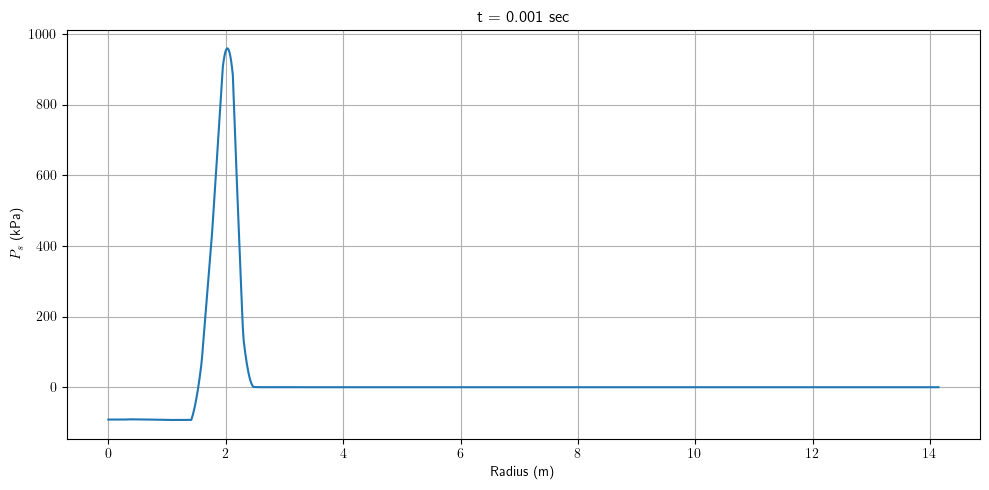

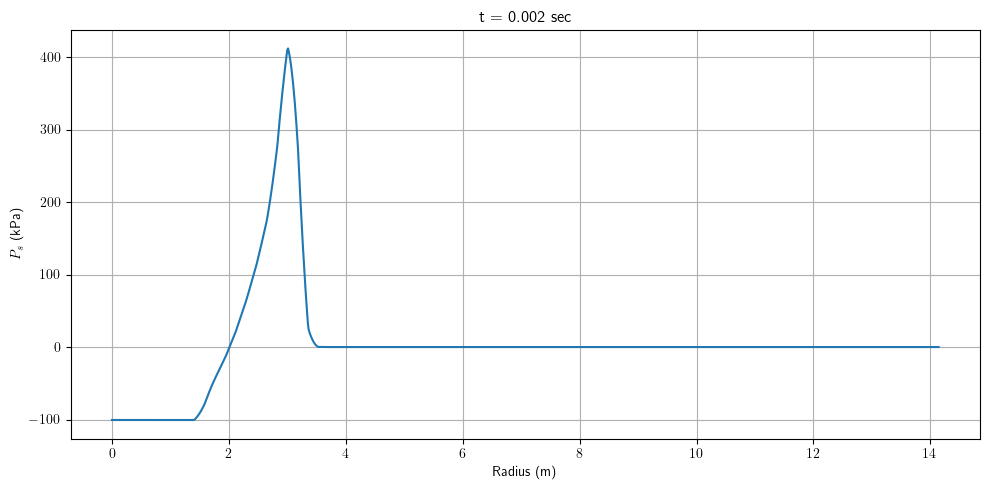

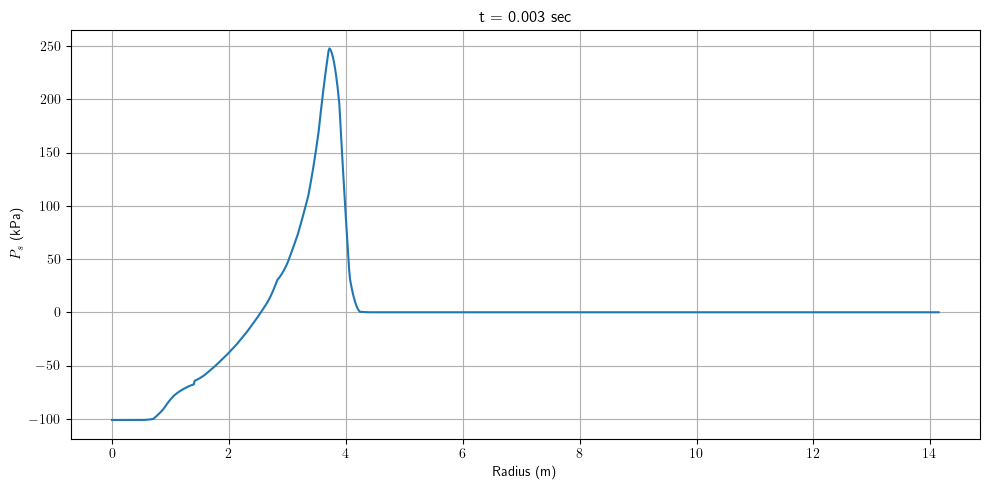

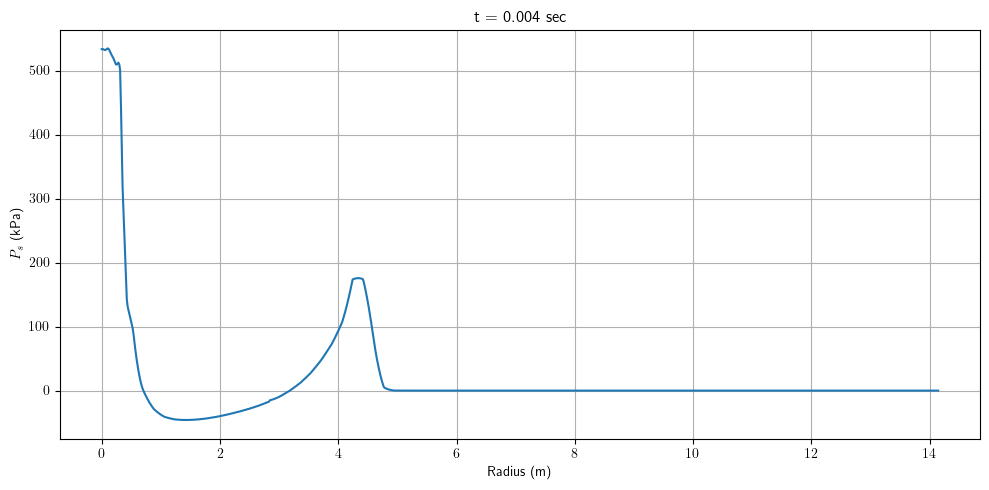

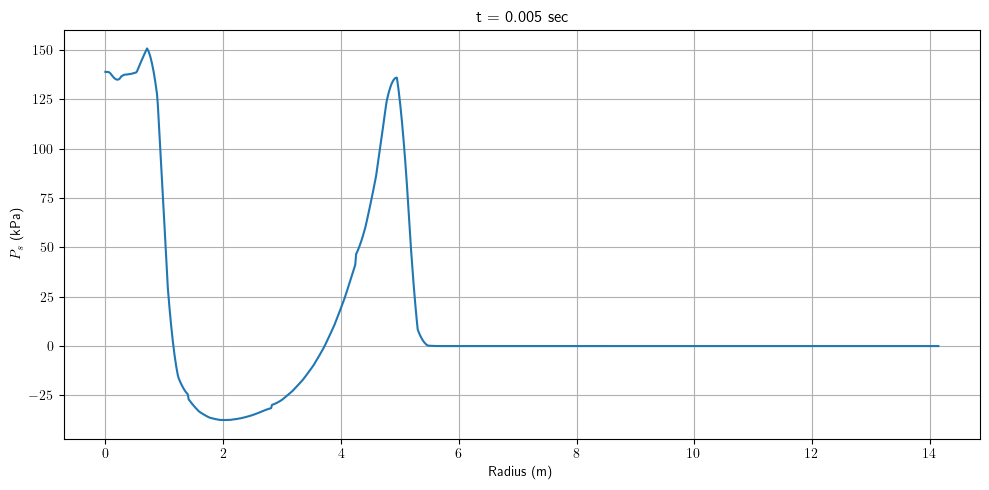

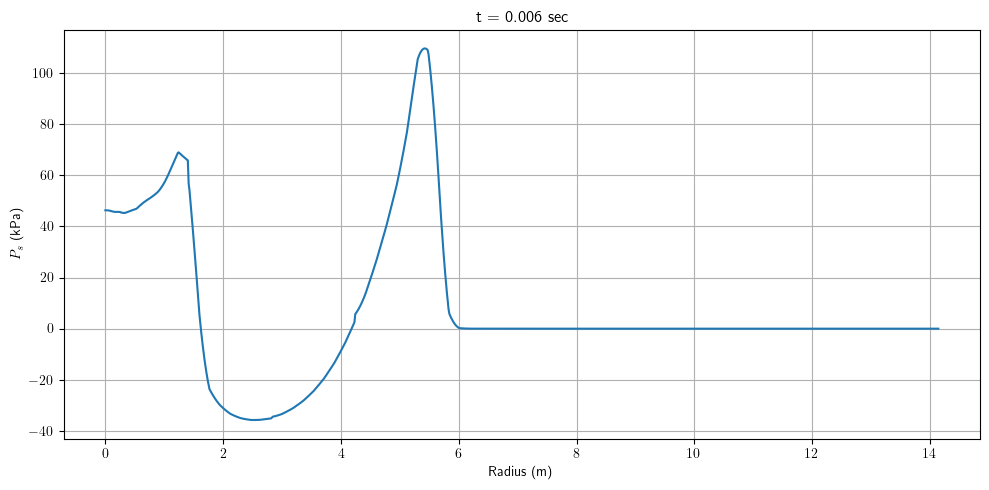

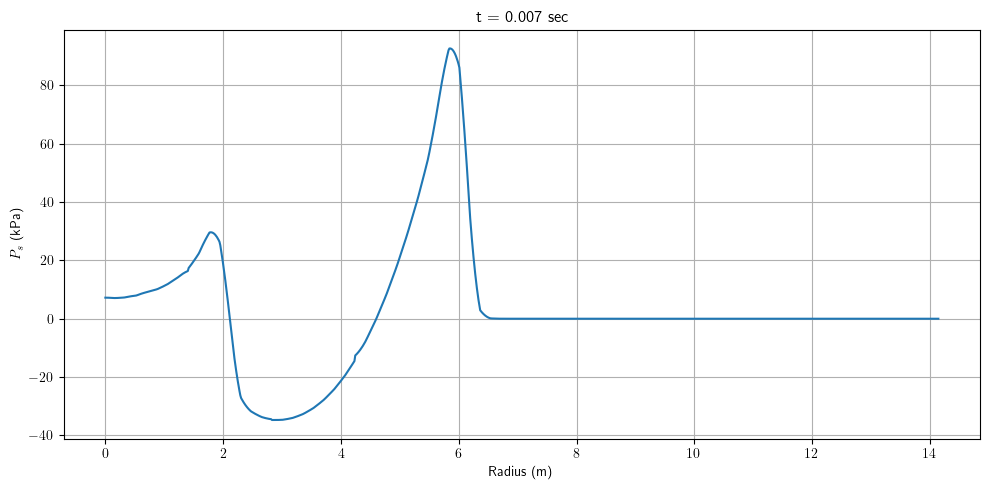

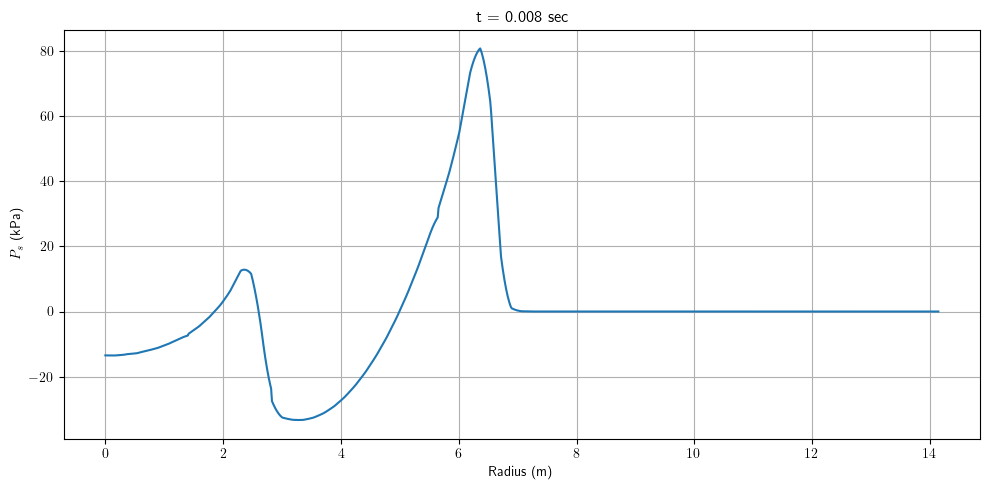

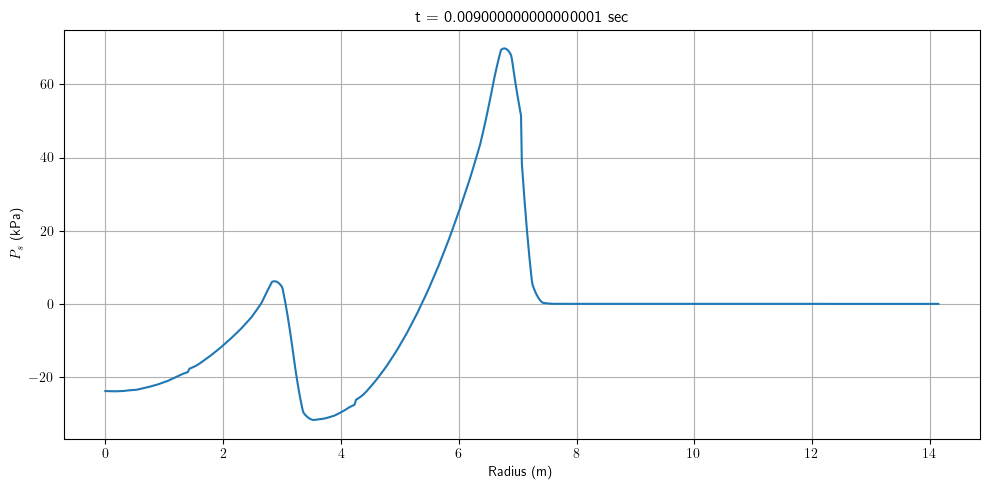

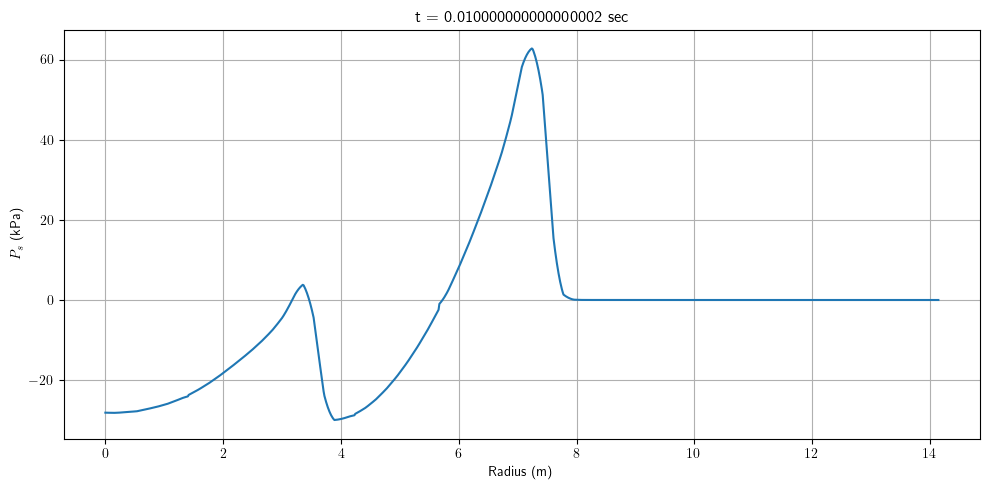

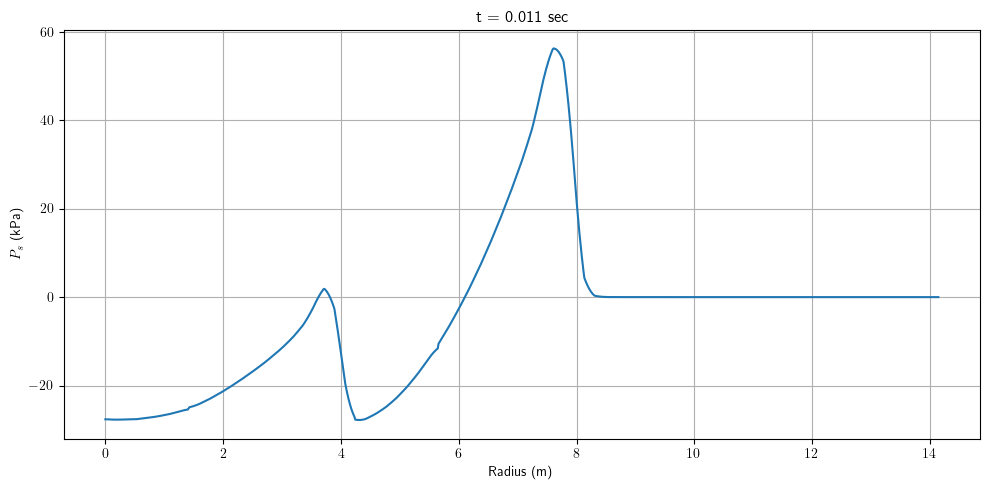

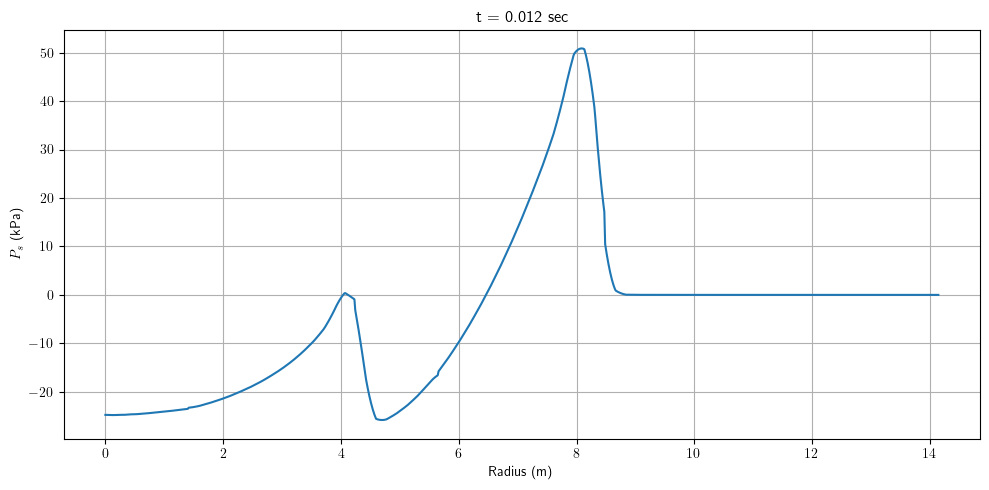

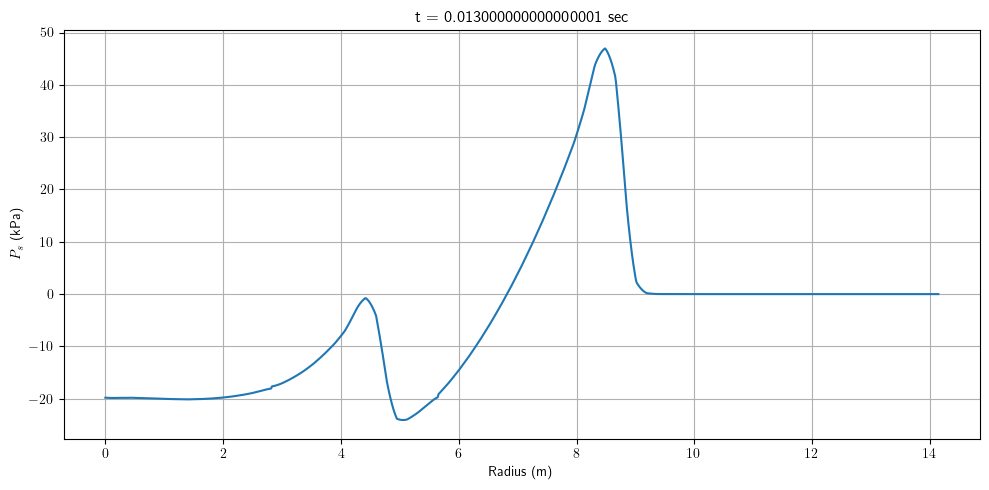

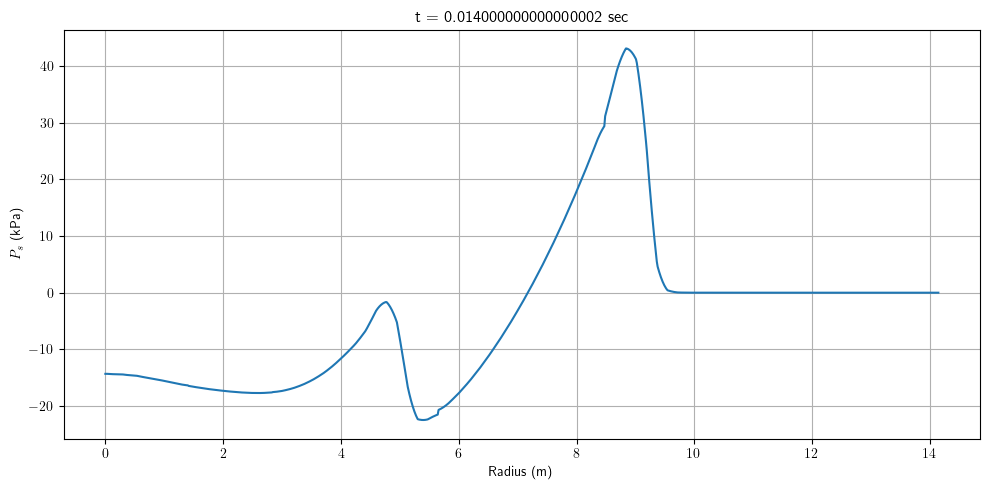

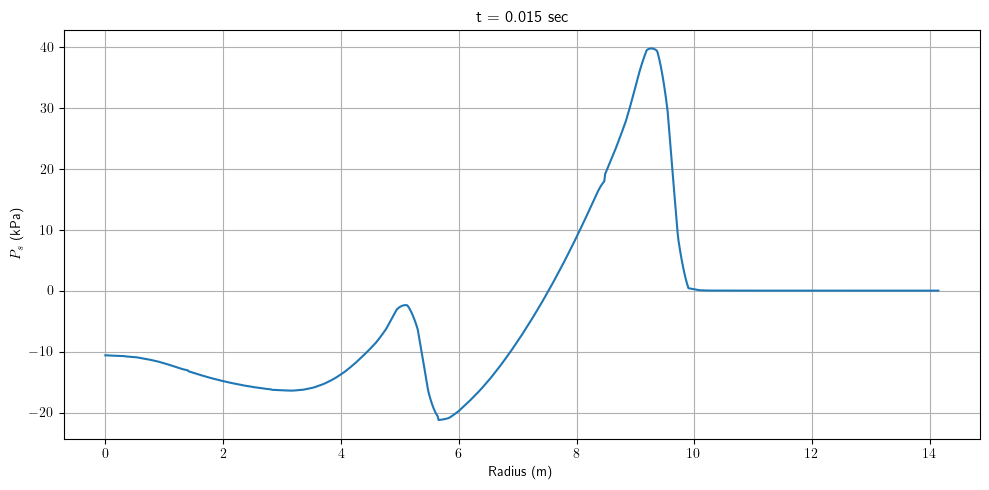

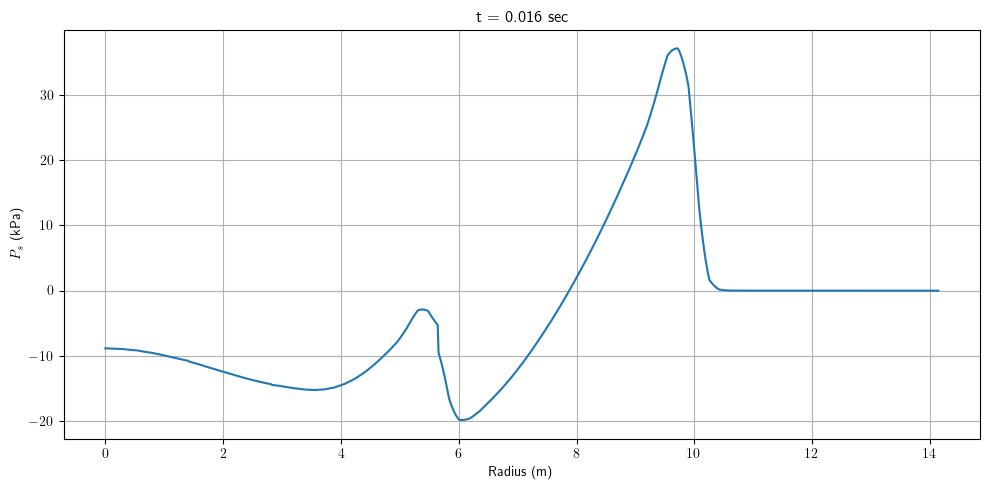

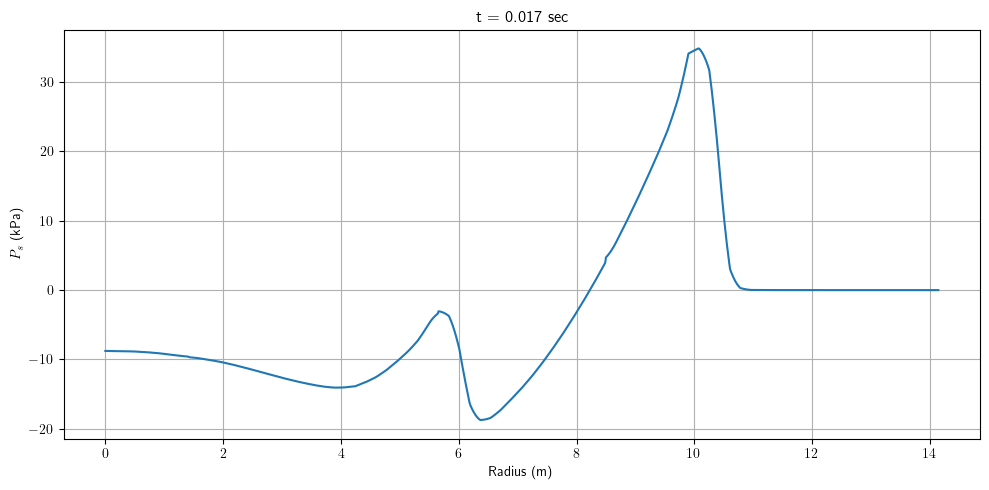

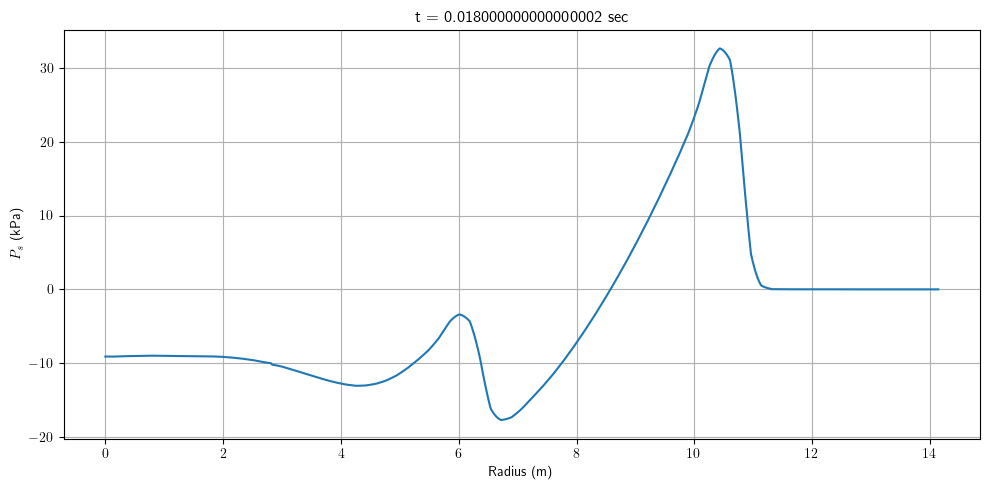

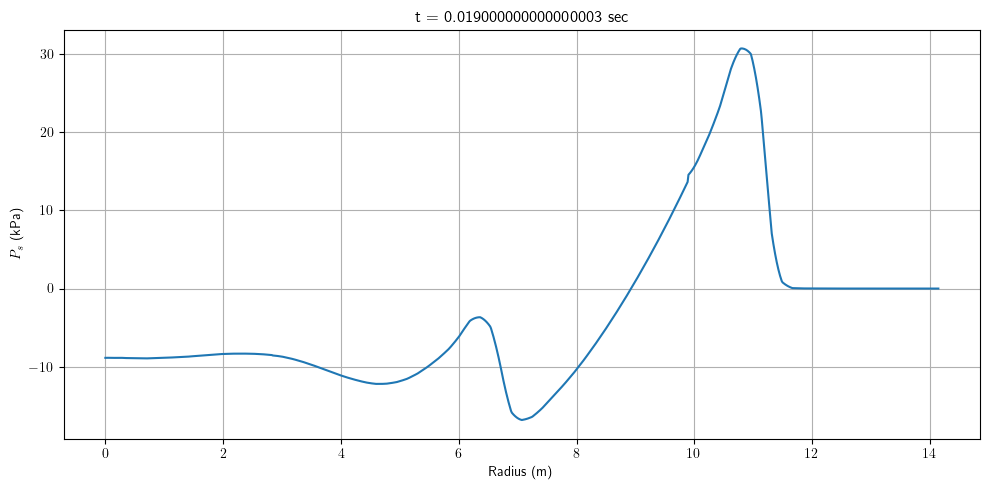

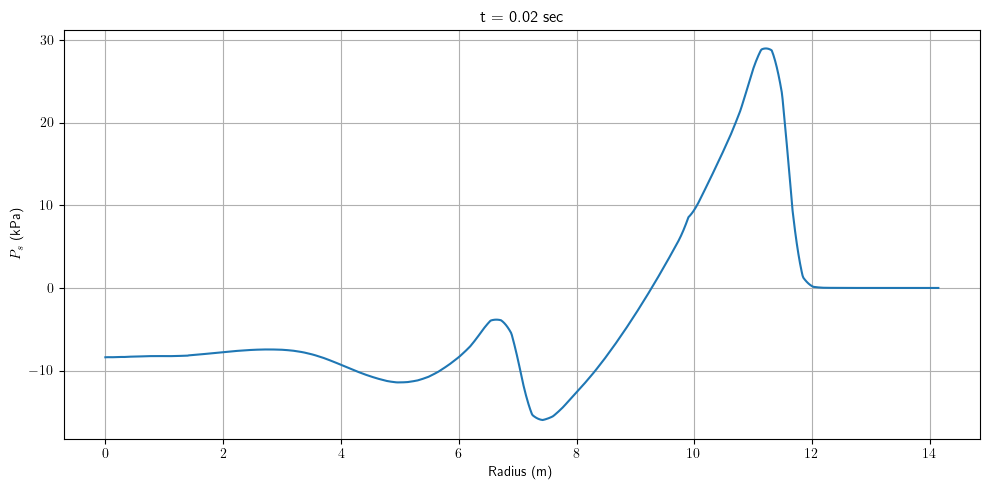

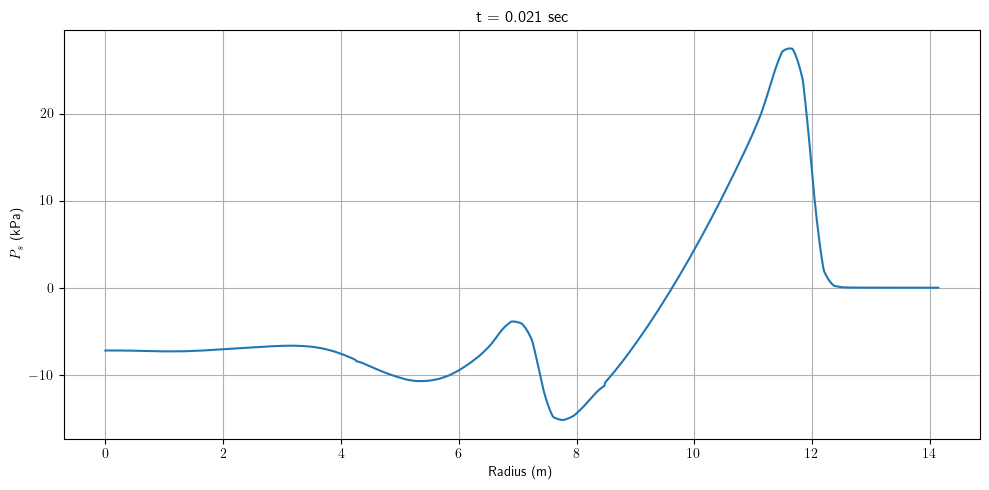

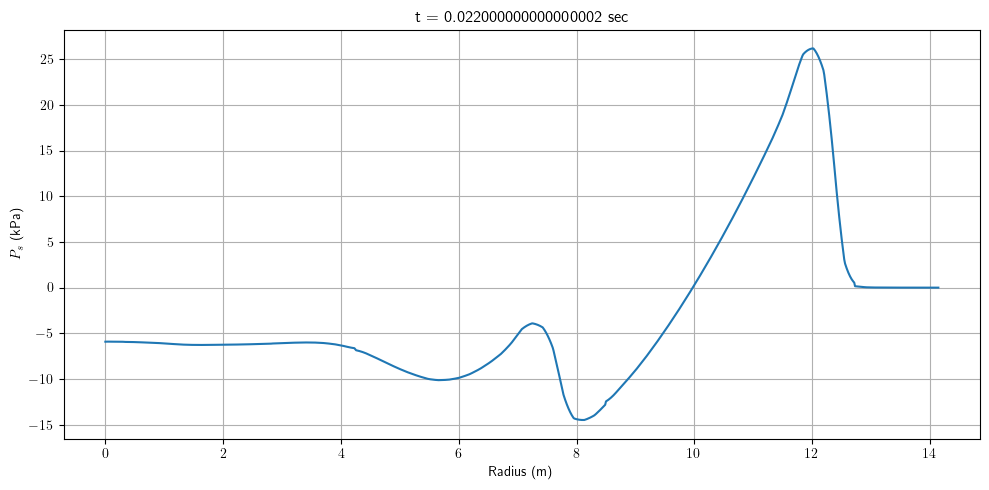

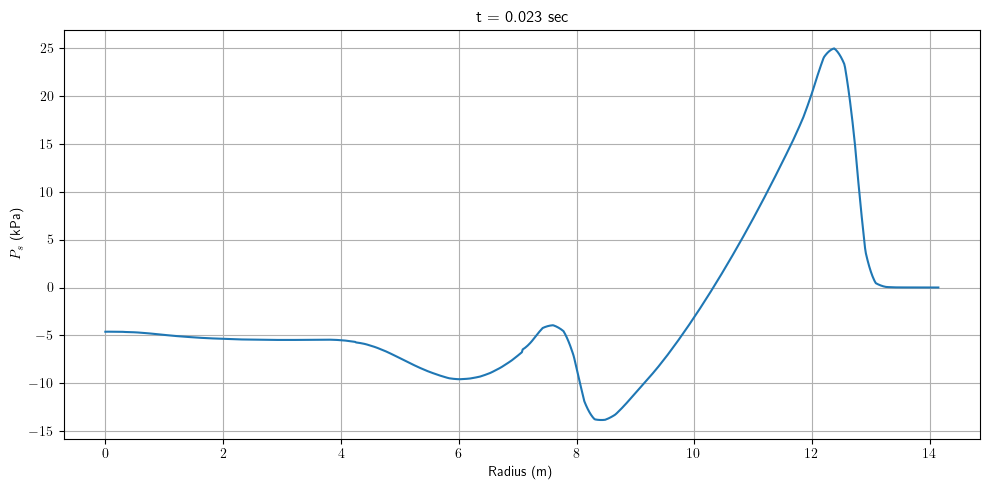

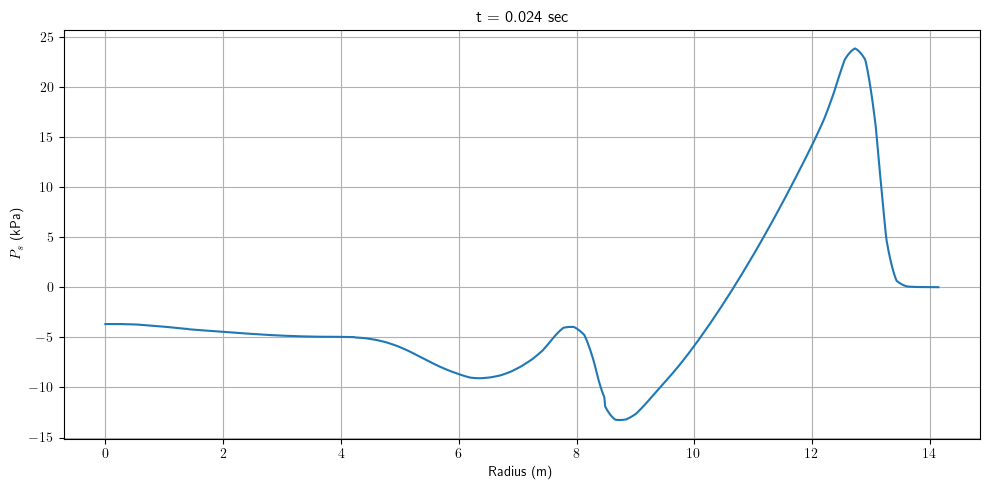

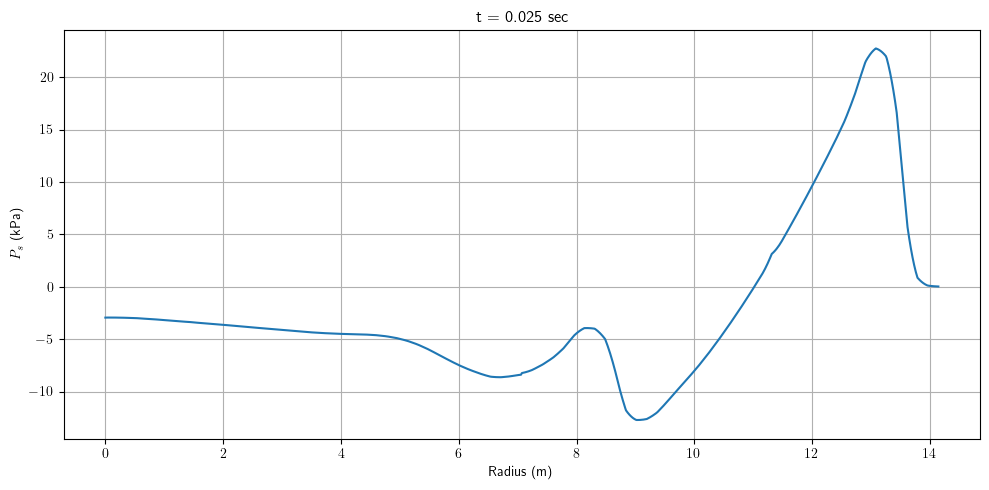

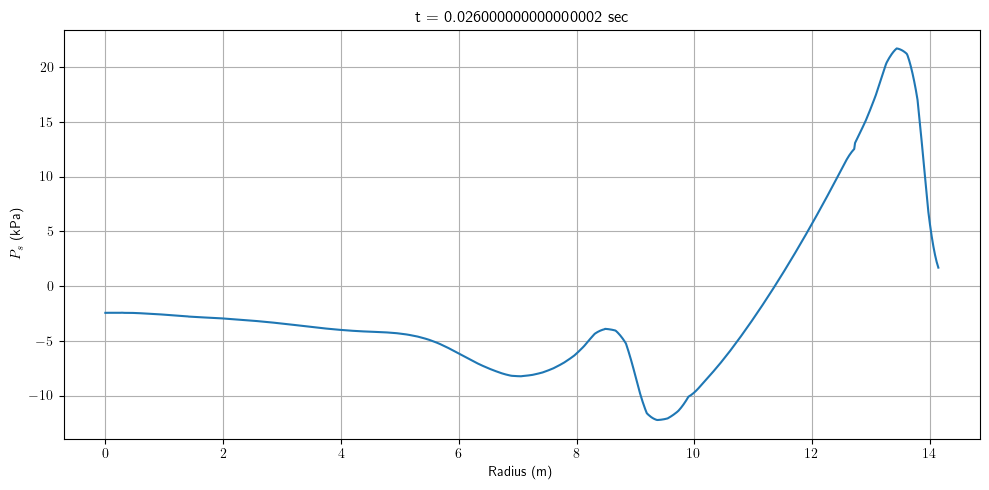

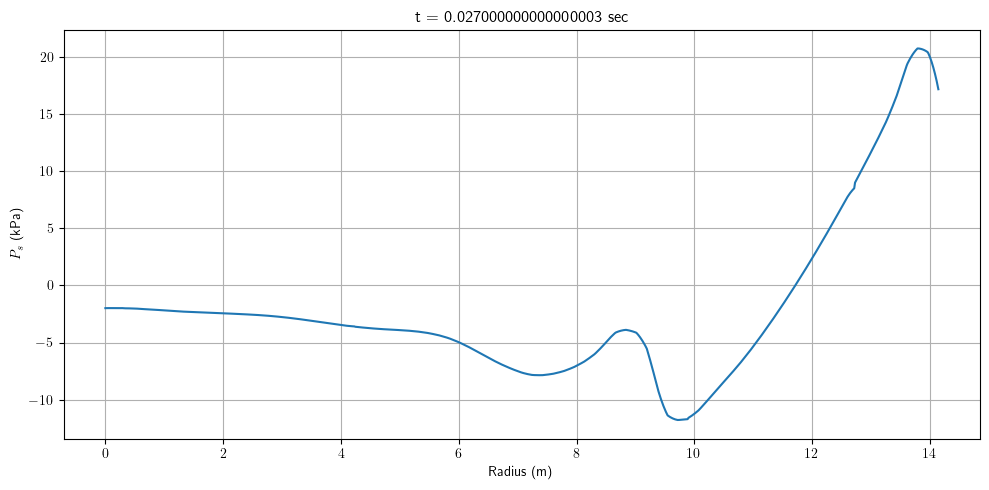

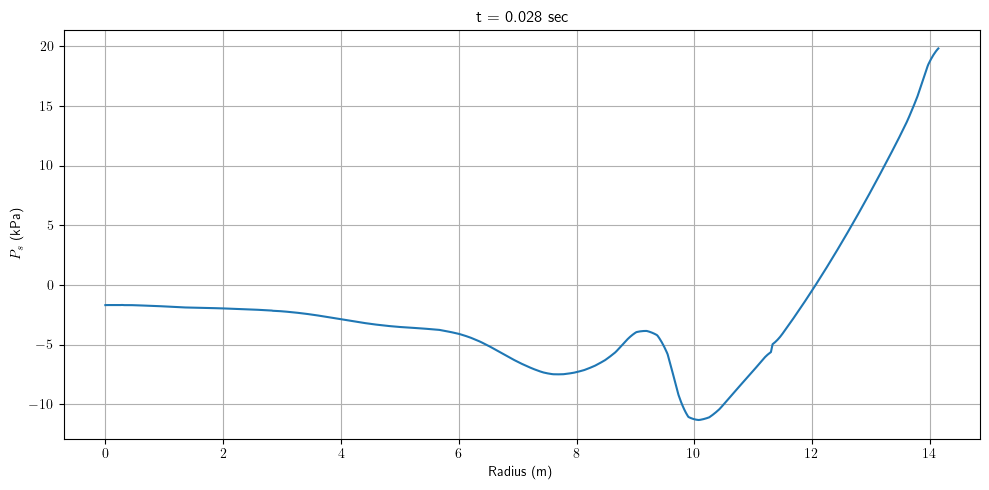

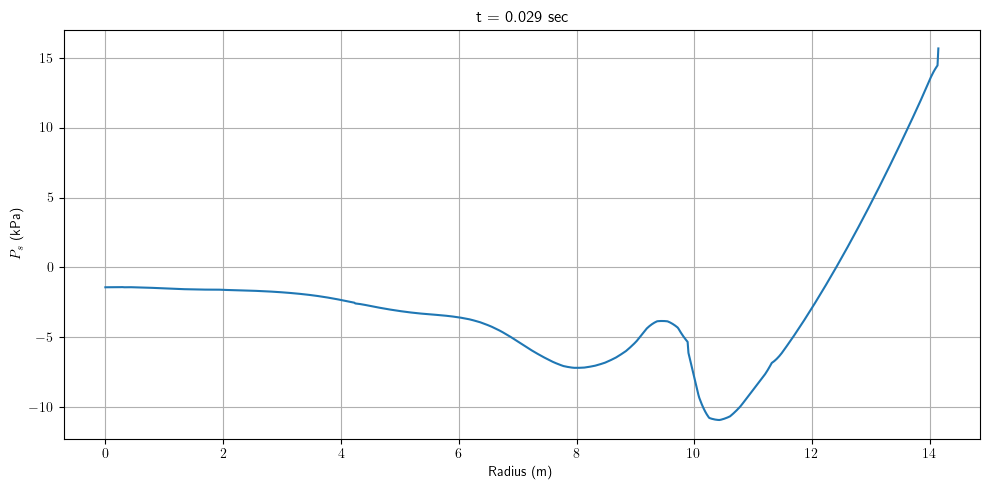

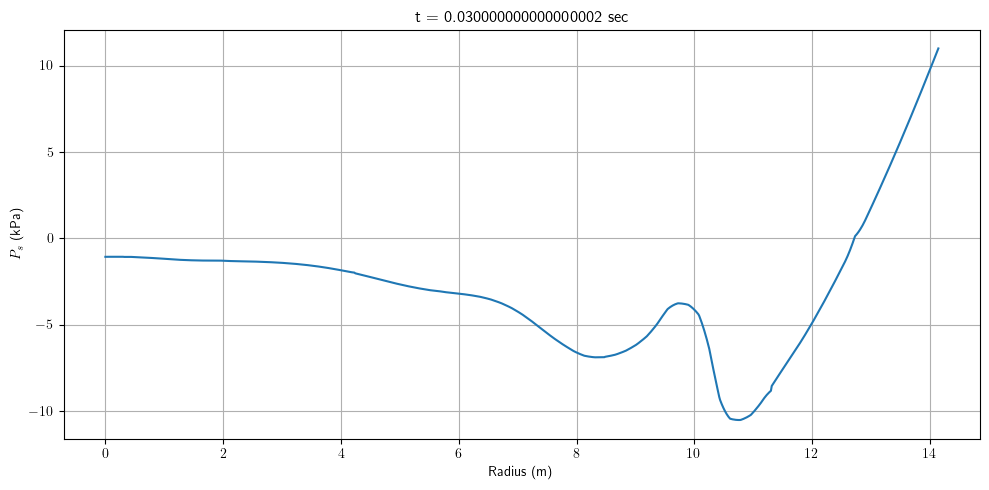

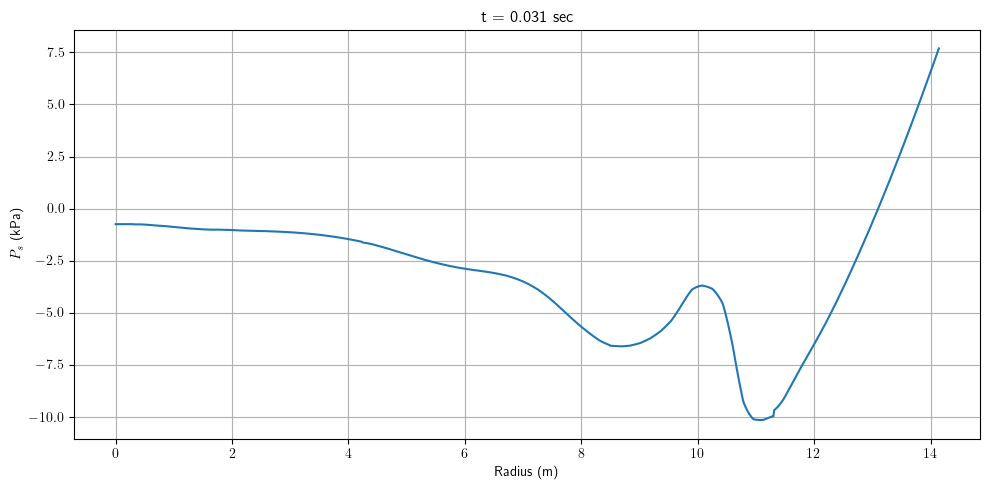

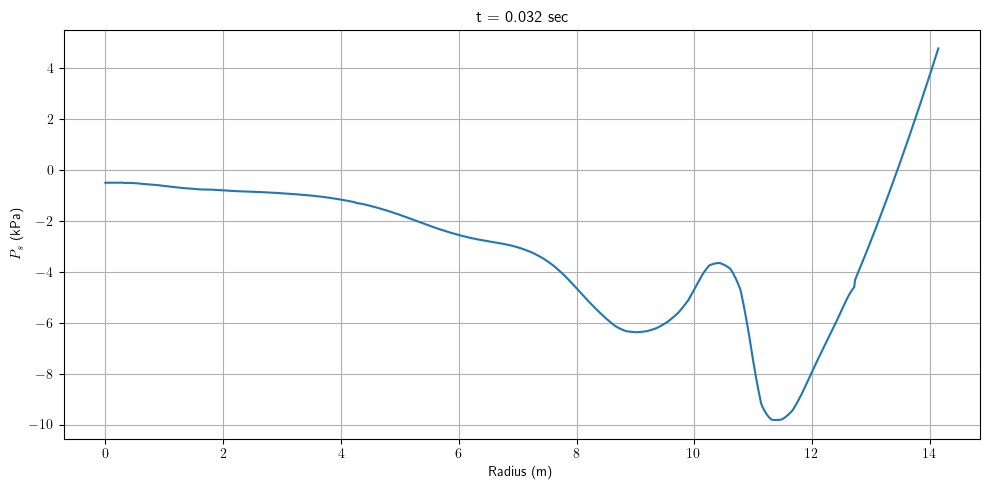

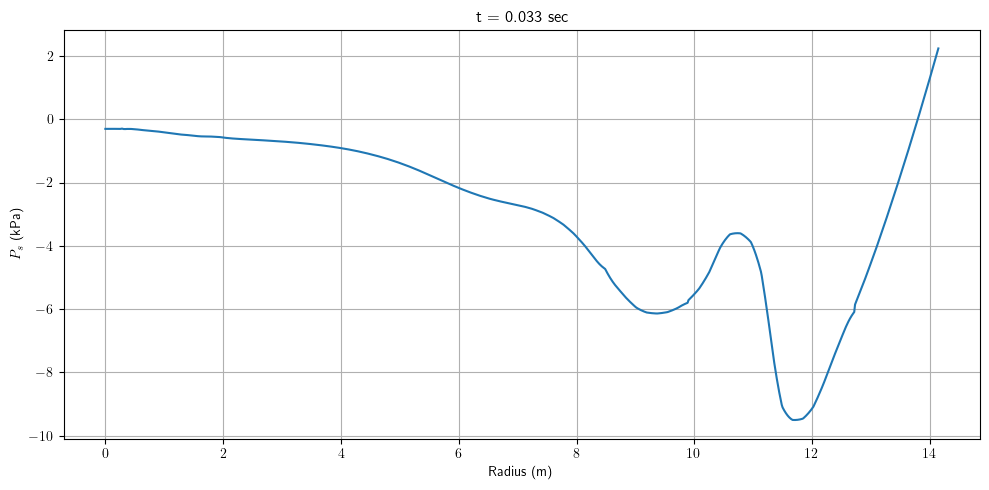

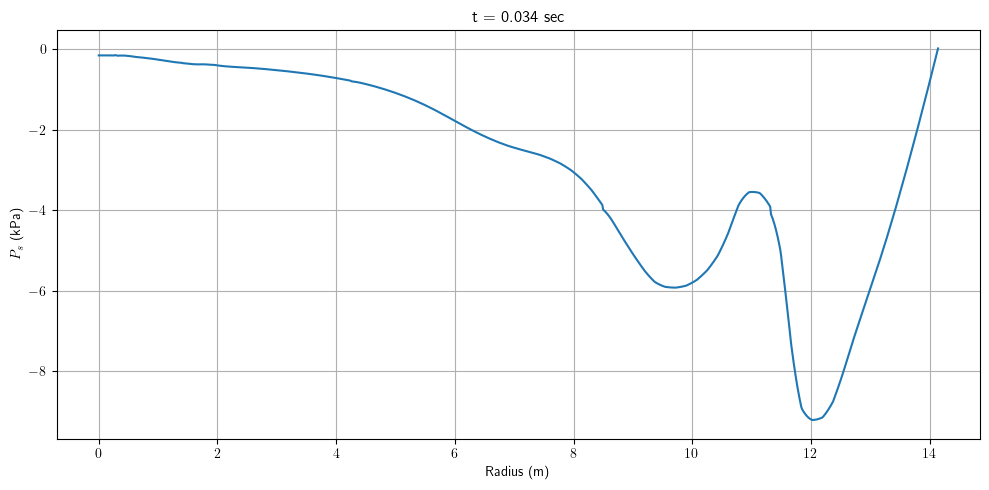

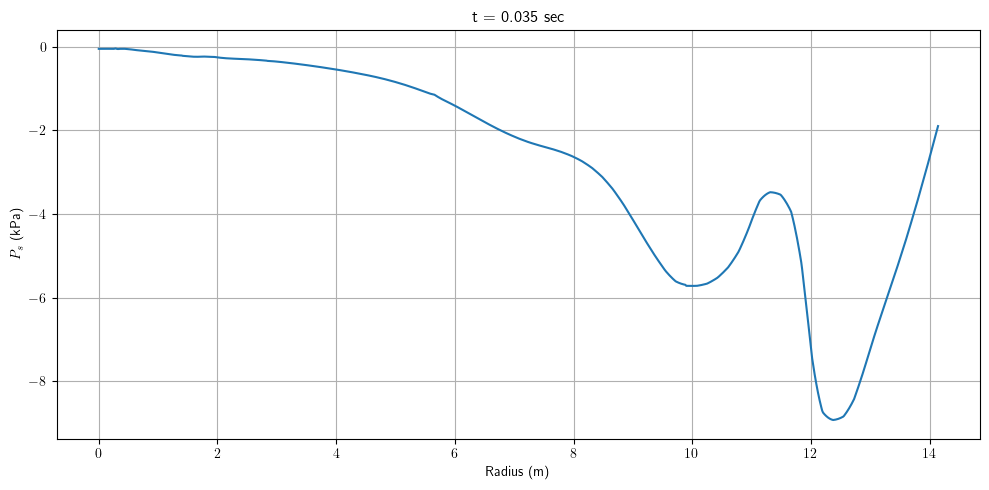

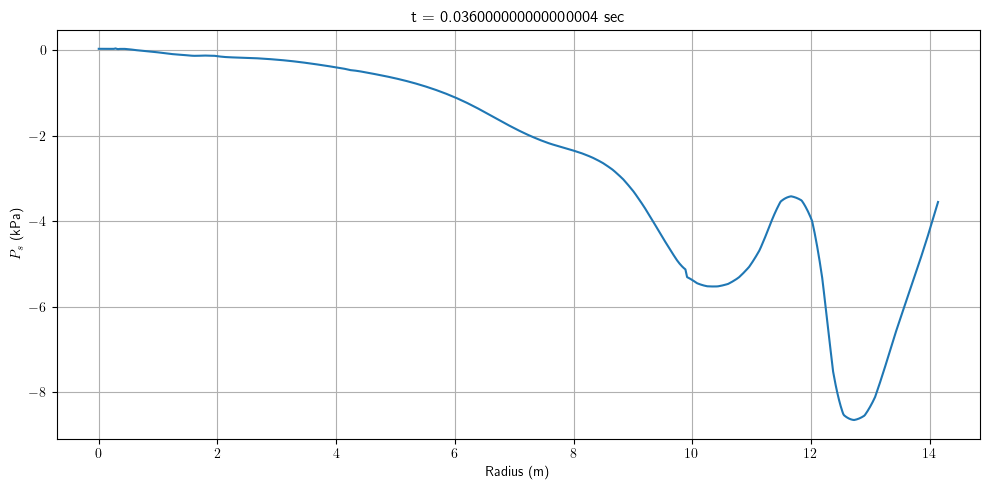

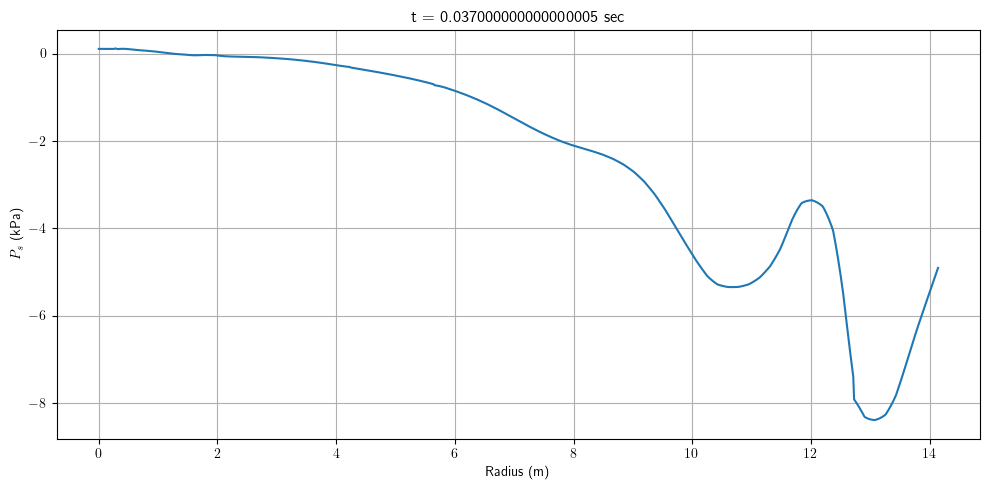

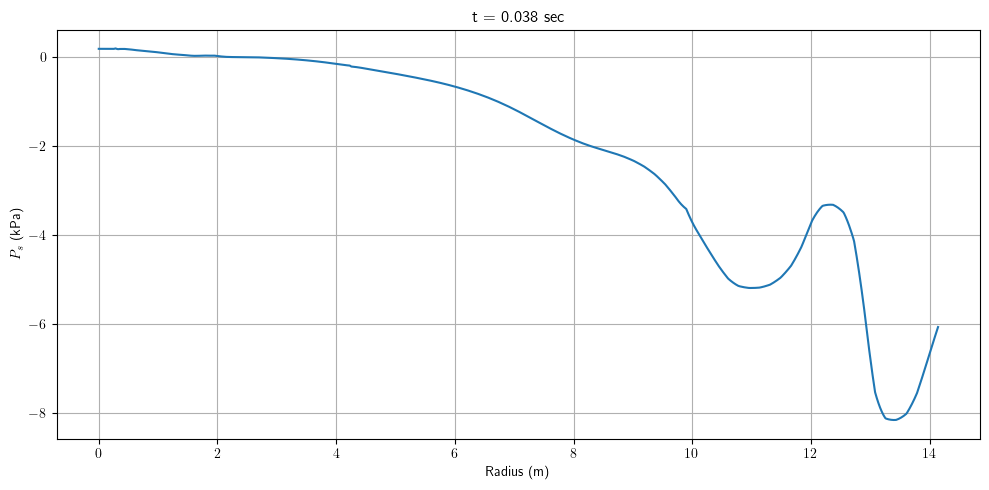

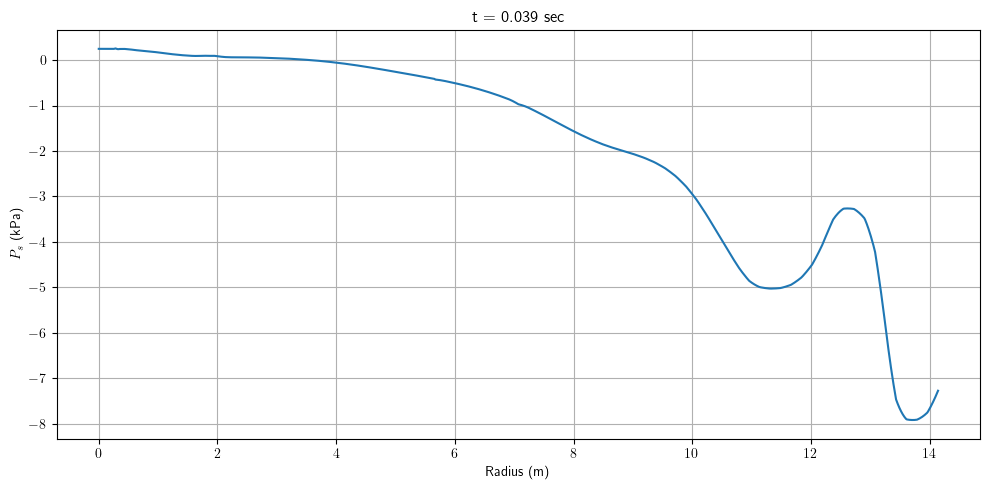

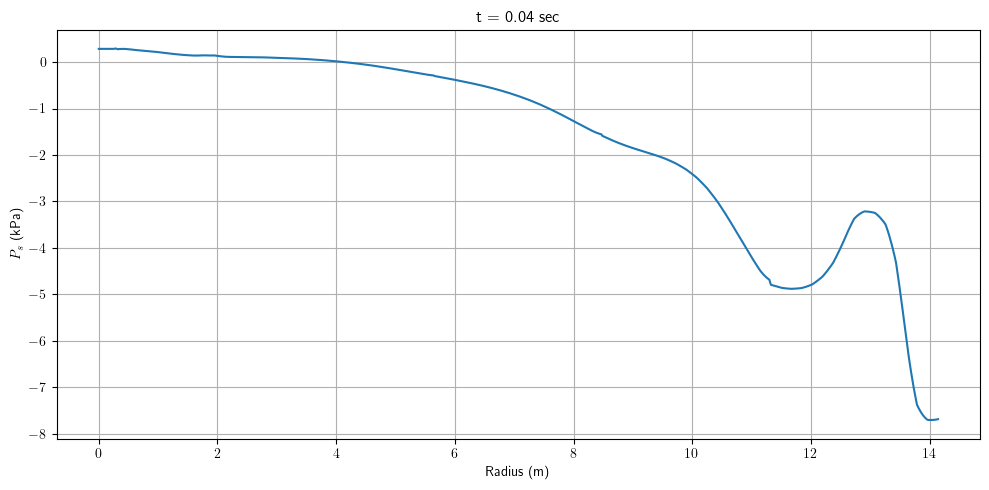

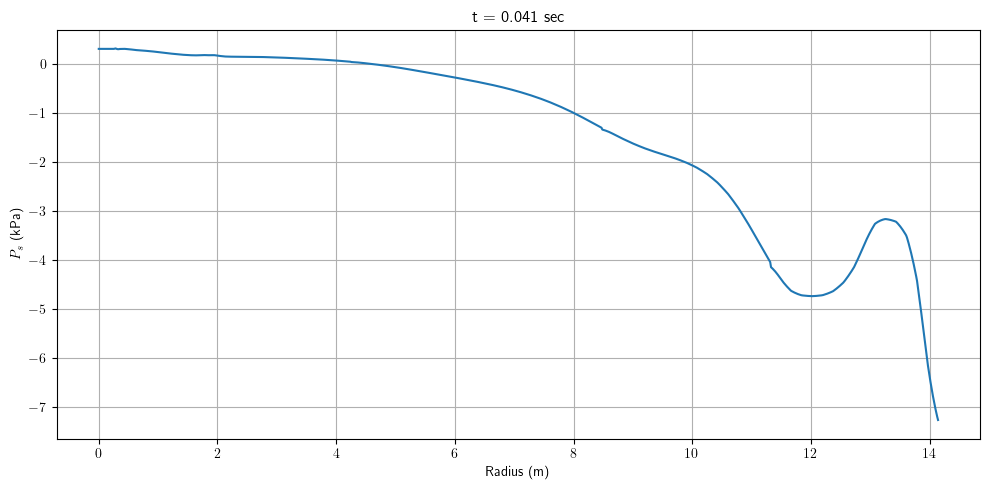

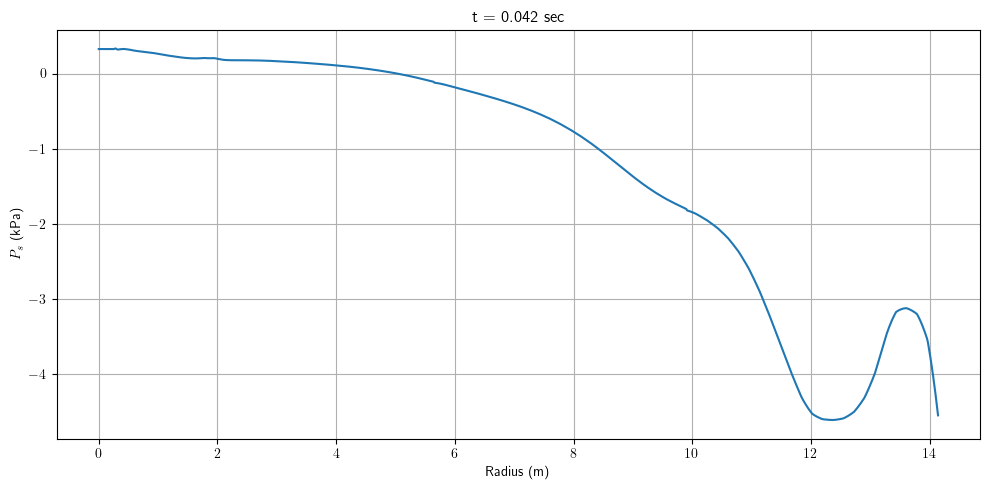

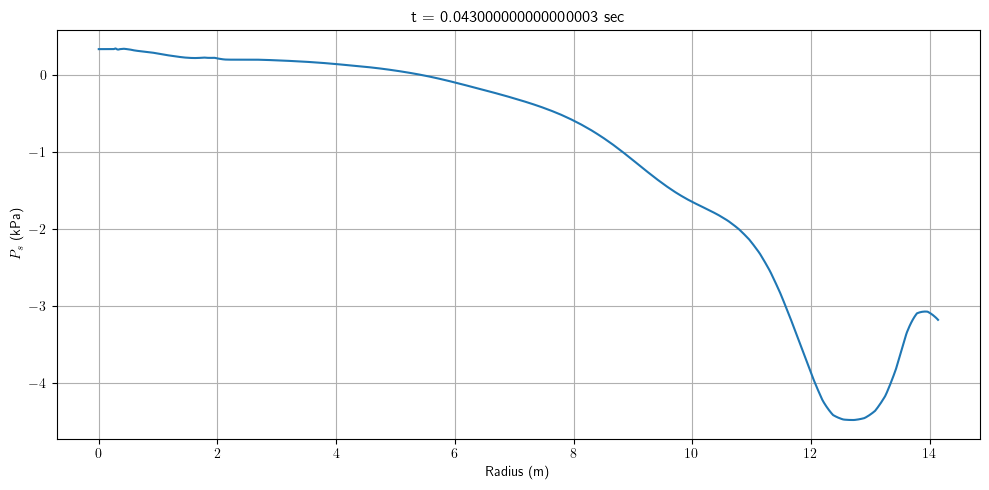

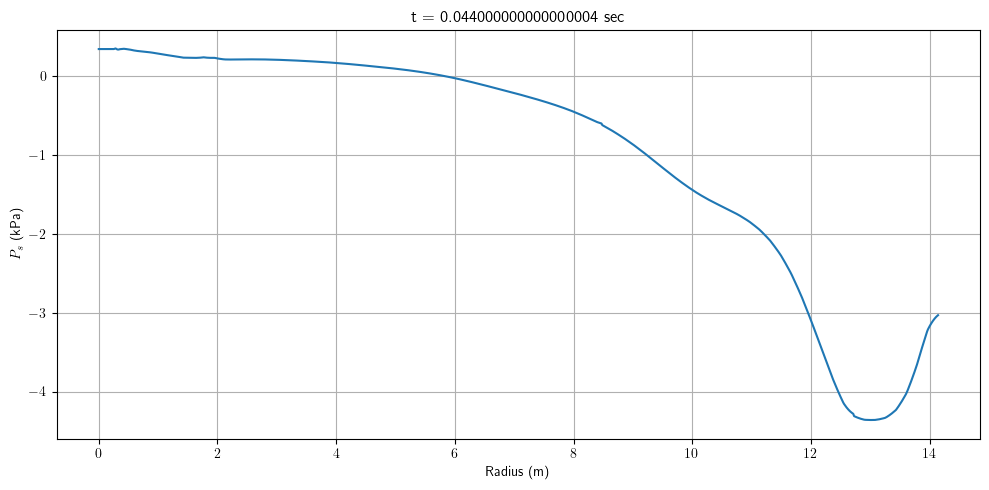

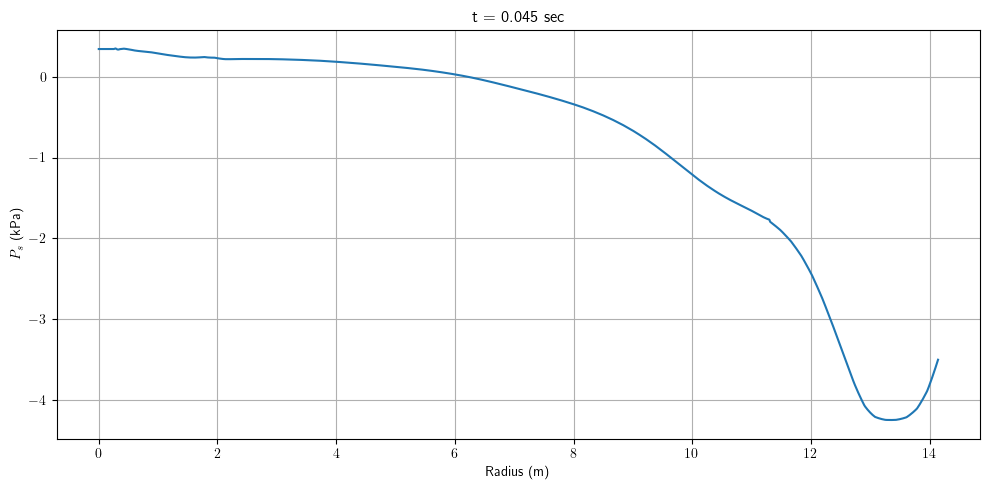

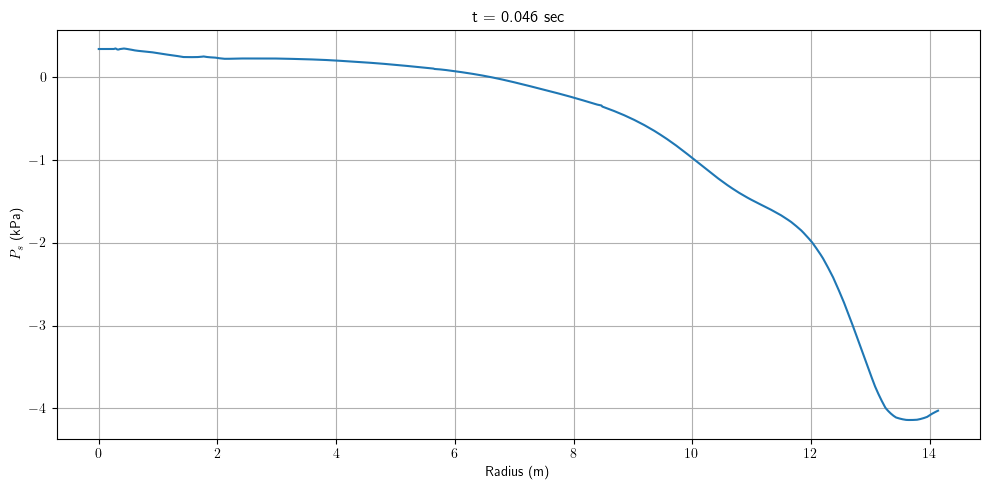

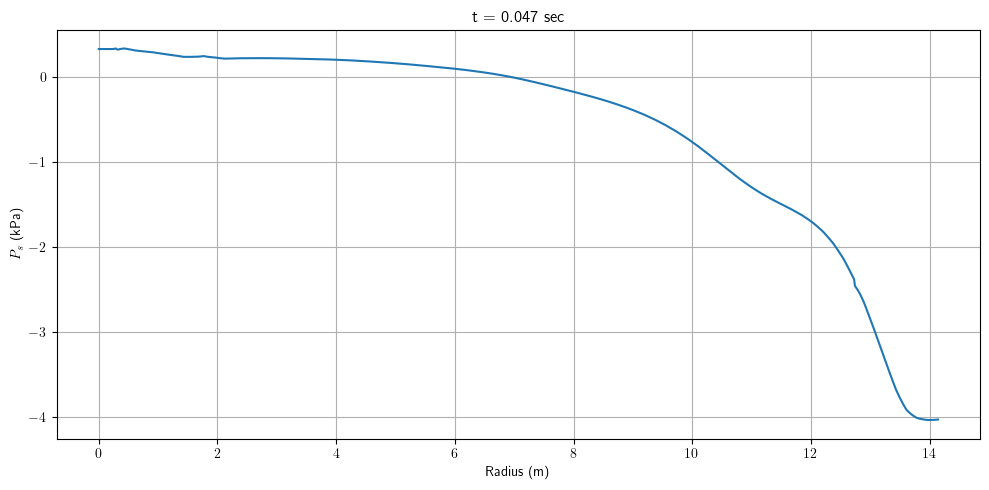

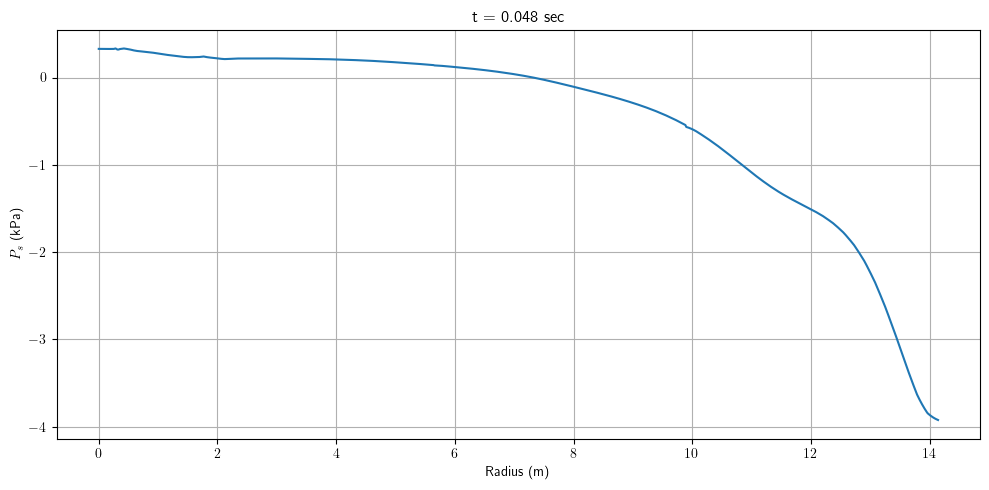

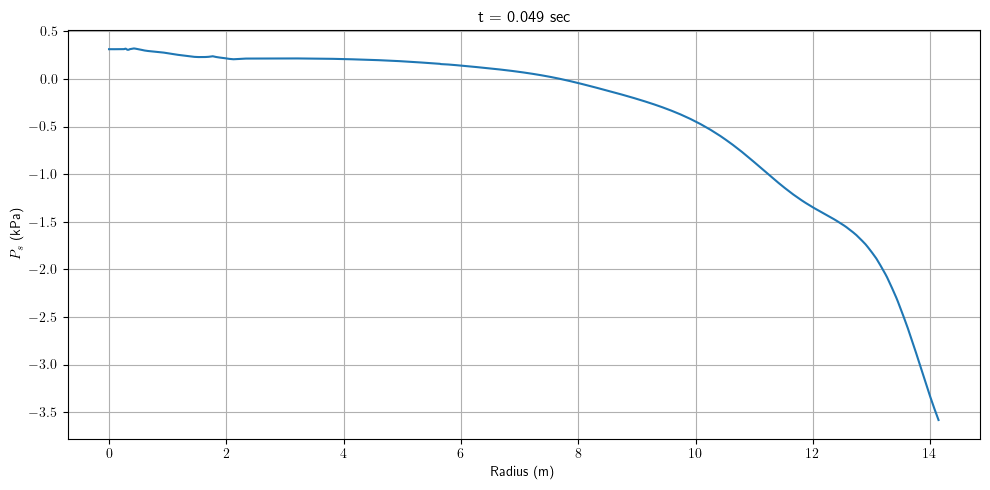

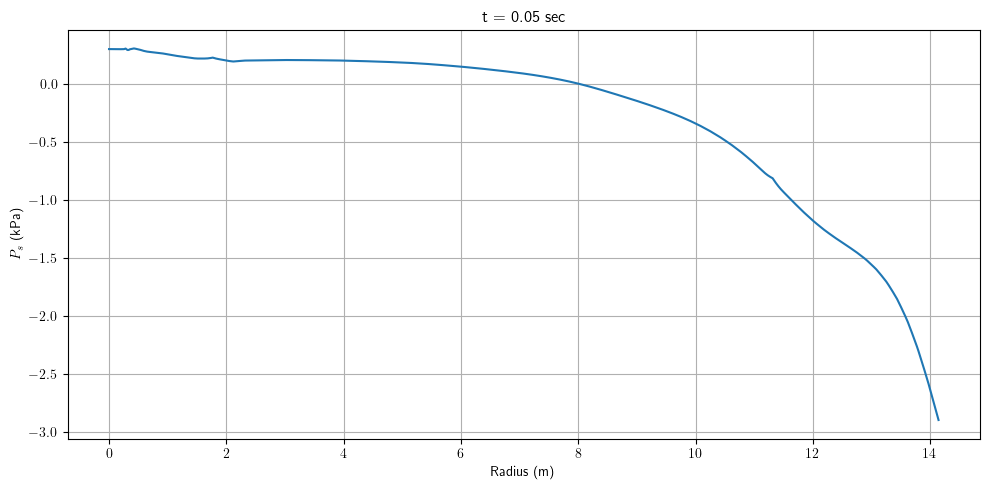

In [34]:
'''Overpressure plots'''
# plotParams(times,r,overpressure,r'$P_{s}$ (kPa)','overpressure',M,1/1000)

plotParams2(times,r,overpressure,r'$P_{s}$ (kPa)','overpressure',N,1/1000)

In [ ]:
'''Velocity magnitude plots'''
plotParams(times,r,V,r'$\left\| U \right\|$ (m/s)','velMag',M)

In [ ]:
'''Time of arrival magnitude plots'''
plotParams(times,r,V,'Time of arrival (sec)','TOA',M)

In [ ]:
'''Individual velocity plots'''
plotParams(times,r,u0,r'$U_{0}$ (m/s)','U0',M)
plotParams(times,r,u1,r'$U_{1}$ (m/s)','U1',M)
plotParams(times,r,u2,r'$U_{2}$ (m/s)','U2',M)

In [20]:
'''Function to plot data at two radii on the same plot'''
def paramTatR(x,params,idx1,idx2,r,ylabel,fn,scale=1):
    # Make the figure
    fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(10,5))

    # Calculate delta r
    deltaR = r[idx2]-r[idx1]

    # Overpressure
    ax.plot(x,params[idx1,:]*scale)
    ax.plot(x,params[idx2,:]*scale)
    ax.set_xlabel('Time (sec)')
    ax.set_ylabel(ylabel)
    ax.set_title(r'$\Delta r$ = ' + str(deltaR) + ' m')
    ax.grid(True)

    # Save the plot
    fig.tight_layout()
    fig.savefig(figDirName + fn + 'dr' + str(deltaR).replace('.',',') + 'm' + '.pdf')

In [ ]:
'''Plot overpressure at two r's on the same plot'''
paramTatR(times,overpressure,5,45,r,r'$P_{s}$ (kPa)','2rOP_for',scale=1/1000)